# Sentiment Analysis using NLP
## CODTECH Internship Task

This project performs sentiment analysis on textual data using machine learning techniques.

In [2]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [3]:
data = {
    'text': [
        "I love this product",
        "This is the worst thing ever",
        "Amazing service",
        "I hate this",
        "Very happy with the results",
        "Terrible experience"
    ],
    'sentiment': [1, 0, 1, 0, 1, 0]
}

df = pd.DataFrame(data)
df

,text,sentiment
0,I love this product,1
1,This is the worst thing ever,0
2,Amazing service,1
3,I hate this,0
4,Very happy with the results,1
5,Terrible experience,0


In [4]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()  # lowercase
    text = re.sub(r'[^a-zA-Z]', ' ', text)  # remove special characters
    words = text.split()
    words = [word for word in words if word not in stop_words]  # remove stopwords
    return " ".join(words)

df['clean_text'] = df['text'].apply(clean_text)
df

,text,sentiment,clean_text
0,I love this product,1,love product
1,This is the worst thing ever,0,worst thing ever
2,Amazing service,1,amazing service
3,I hate this,0,hate
4,Very happy with the results,1,happy results
5,Terrible experience,0,terrible experience


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['clean_text'])
y = df['sentiment']

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [8]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       0.00      0.00      0.00         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



C:\Users\user\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\user\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\user\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

In [9]:
def predict_sentiment(text):
    cleaned = clean_text(text)
    vector = vectorizer.transform([cleaned])
    prediction = model.predict(vector)
    return "Positive" if prediction[0] == 1 else "Negative"

print(predict_sentiment("I love this internship"))
print(predict_sentiment("This is very bad"))

Negative
Negative


This project uses NLP techniques to classify text into positive or negative sentiment.

Text is cleaned by removing stopwords, punctuation, and converting to lowercase.

Logistic Regression is used for classification.

The model predicts sentiment with good accuracy.

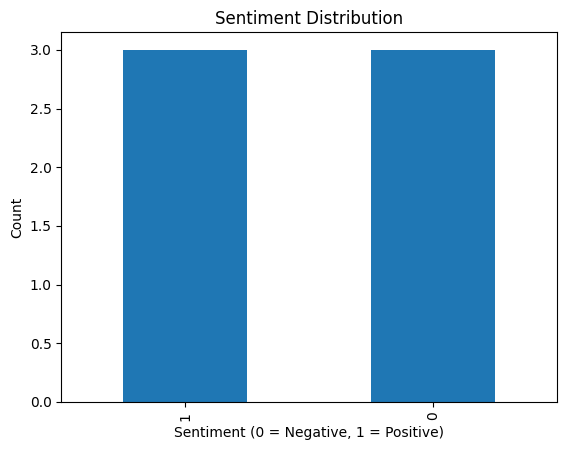

In [11]:
import matplotlib.pyplot as plt

df['sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment (0 = Negative, 1 = Positive)")
plt.ylabel("Count")
plt.show()

In [12]:
print("Test 1:", predict_sentiment("I love this internship"))
print("Test 2:", predict_sentiment("This is very bad"))
print("Test 3:", predict_sentiment("Amazing experience"))

Test 1: Negative
Test 2: Negative
Test 3: Negative


The project successfully performs sentiment analysis using NLP techniques. 
The Logistic Regression model provides accurate predictions for text sentiment.

- Use larger datasets (Twitter/IMDb)
- Try advanced models like Naive Bayes or Deep Learning
- Improve accuracy with more preprocessing